## 0. Setup & Data Ingestion
imports, kagglehub data download, dataset summary

In [1]:
import kagglehub
import os

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams["figure.figsize"] = (4, 2.5) # standardizing plot size (small plots)

# Download latest version
path = kagglehub.dataset_download("amitanshjoshi/spotify-1million-tracks")
print("Path to dataset files:", path)

full_path = os.path.join(path, os.listdir(path)[0])
df = pd.read_csv(full_path).drop(columns=['Unnamed: 0'])

df.head().T

Path to dataset files: /Users/cjz/.cache/kagglehub/datasets/amitanshjoshi/spotify-1million-tracks/versions/1


,0,1,2,3,4
artist_name,Jason Mraz,Jason Mraz,Joshua Hyslop,Boyce Avenue,Andrew Belle
track_name,I Won't Give Up,93 Million Miles,Do Not Let Me Go,Fast Car,Sky's Still Blue
track_id,53QF56cjZA9RTuuMZDrSA6,1s8tP3jP4GZcyHDsjvw218,7BRCa8MPiyuvr2VU3O9W0F,63wsZUhUZLlh1OsyrZq7sz,6nXIYClvJAfi6ujLiKqEq8
popularity,68,50,57,58,54
year,2012,2012,2012,2012,2012
genre,acoustic,acoustic,acoustic,acoustic,acoustic
danceability,0.483,0.572,0.409,0.392,0.43
energy,0.303,0.454,0.234,0.251,0.791
key,4,3,3,10,6
loudness,-10.058,-10.286,-13.711,-9.845,-5.419


In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1159764 entries, 0 to 1159763
Data columns (total 19 columns):
 #   Column            Non-Null Count    Dtype  
---  ------            --------------    -----  
 0   artist_name       1159749 non-null  str    
 1   track_name        1159763 non-null  str    
 2   track_id          1159764 non-null  str    
 3   popularity        1159764 non-null  int64  
 4   year              1159764 non-null  int64  
 5   genre             1159764 non-null  str    
 6   danceability      1159764 non-null  float64
 7   energy            1159764 non-null  float64
 8   key               1159764 non-null  int64  
 9   loudness          1159764 non-null  float64
 10  mode              1159764 non-null  int64  
 11  speechiness       1159764 non-null  float64
 12  acousticness      1159764 non-null  float64
 13  instrumentalness  1159764 non-null  float64
 14  liveness          1159764 non-null  float64
 15  valence           1159764 non-null  float64
 16  tempo      

## 1. Data Quality
dropping nulls, duplicate checks

In [3]:
sums = df.isnull().sum()
sums[sums > 0] # output cols with null values

artist_name    15
track_name      1
dtype: int64

In [4]:
df.duplicated().sum()

np.int64(0)

## 2. EDA
correlations, distributions, domain checks

### 2.1 - Correlations

In [5]:
corr1 = df.corr(numeric_only=True) # correlation matrix

high_corr_pairs = (corr1[(corr1 < 1) & (abs(corr1) > 0.35)] # initial filter
              .unstack().dropna() # drop na values caused by filter
              .sort_values(ascending=False, key=abs)[::2]) # sort values and take only one instance of each pair

sums1 = abs(corr1[(corr1 < 1)]).sum() # sum of valid absolute correlations for each feature

print(high_corr_pairs)
sums1.sort_values(ascending=False)[:5]

energy        loudness            0.781006
              acousticness       -0.752662
loudness      acousticness       -0.621698
danceability  valence             0.519900
loudness      instrumentalness   -0.403575
dtype: float64


loudness        3.117760
energy          2.976817
acousticness    2.472018
valence         2.028640
danceability    1.915770
dtype: float64

### 2.2 - Distributions

In [6]:
def distplots(df, feature_cols, n_plot_cols=4):
    n = len(feature_cols)
    rows = (n + n_plot_cols - 1) // n_plot_cols

    fig, axes = plt.subplots(rows, n_plot_cols, figsize=(12, 2.5 * rows))
    axes = axes.flatten()

    for ax, col in zip(axes, feature_cols):
        sns.histplot(df[col], bins=50, ax=ax)
        ax.set_title(col, fontsize=9)
        try:
            ax.set_xlabel(f"skew={df[col].skew():.2f}")
        except Exception:
            pass

    for ax in axes[n:]:
        ax.set_visible(False)

    plt.tight_layout()
    plt.show()

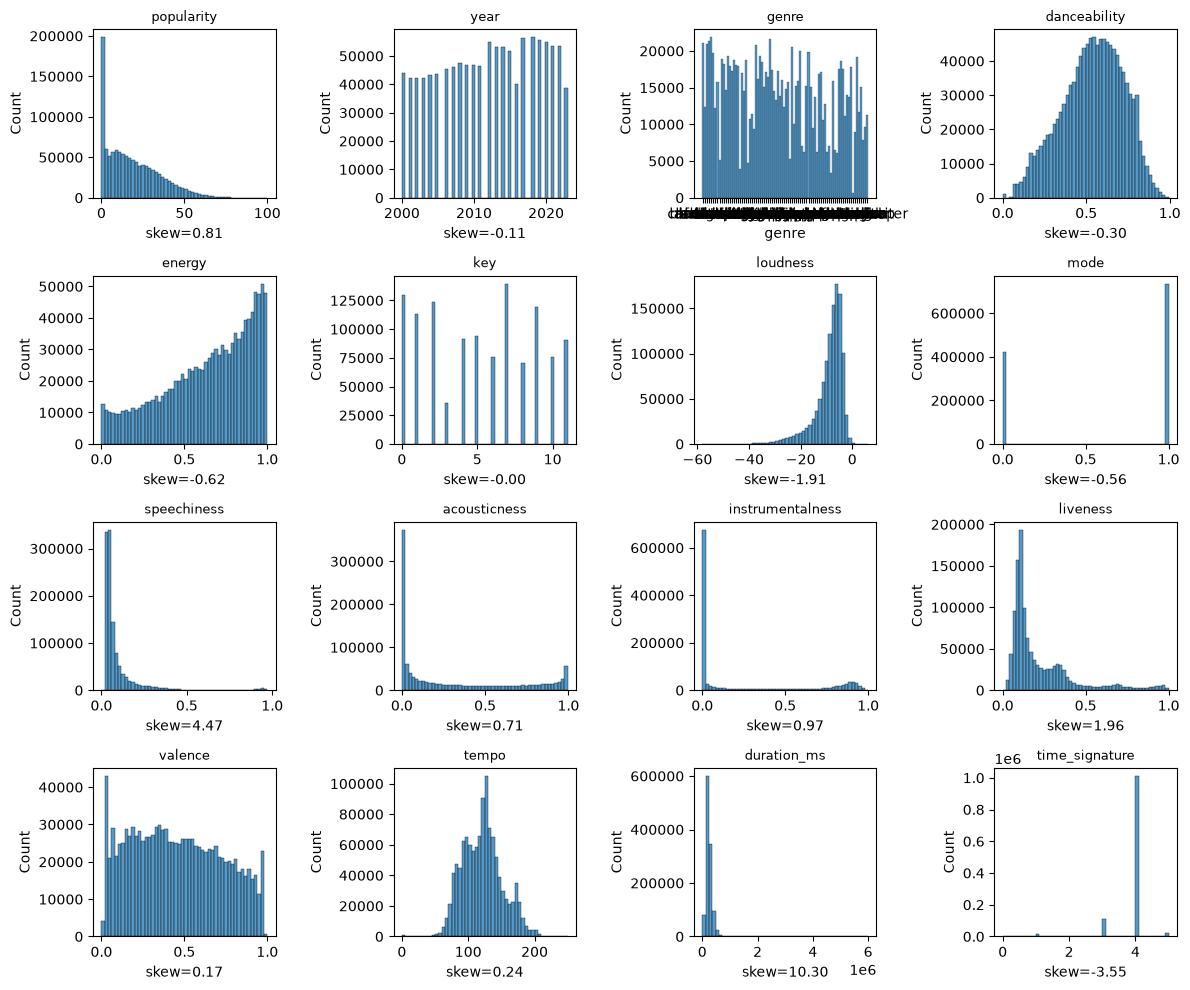

In [7]:
distplots(df, df.columns[3:])

### 2.3 - Domain / Outlier Checks

#### genre

In [8]:
print(df["genre"].value_counts())
print(df["genre"].unique())

genre
black-metal       21852
gospel            21621
ambient           21389
acoustic          21097
alt-rock          20918
                  ...  
chicago-house      5170
dubstep            4774
detroit-techno     3920
rock               3319
songwriter          589
Name: count, Length: 82, dtype: int64
<ArrowStringArray>
[         'acoustic',          'afrobeat',          'alt-rock',
           'ambient',       'black-metal',             'blues',
         'breakbeat',          'cantopop',     'chicago-house',
             'chill',         'classical',              'club',
            'comedy',           'country',             'dance',
         'dancehall',       'death-metal',        'deep-house',
    'detroit-techno',             'disco',     'drum-and-bass',
               'dub',           'dubstep',               'edm',
           'electro',        'electronic',               'emo',
              'folk',             'forro',            'french',
              'funk',            

In [9]:
df[df["genre"].isin(["sleep", "comedy"])].sample(5)

,artist_name,track_name,track_id,popularity,year,genre,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms,time_signature
1027503,The Lonely Island,Dick In A Box,60VtX59NsRINDnObbDtH7G,49,2009,comedy,0.542,0.6990,8,-6.029,1,0.3060,0.401,0.000000,0.105,0.6870,76.391,161053,4
471658,Samira Tesfay,Yearning,2eEmTR3Z7KnbZ6wkctRIjO,50,2020,sleep,0.173,0.0074,8,-33.416,1,0.0392,0.989,0.829000,0.117,0.0395,75.101,144500,4
704469,Yoga,Endless Tropics,3i4p7GlAMEKXDKMcin67g9,0,2001,sleep,0.237,0.0704,0,-26.254,1,0.0486,0.835,0.806000,0.111,0.0343,71.644,178400,4
376022,Leland Klassen,Bed Pan,06FxNyJG4lNaf2QQi606t0,17,2019,comedy,0.494,0.8090,2,-13.663,1,0.9070,0.684,0.000000,0.638,0.4490,103.738,165966,3
319206,Joe Zimmerman,Opening Remarks,258o0w2S3ba5P8LfOvNuA7,25,2018,comedy,0.380,0.9890,2,-8.878,1,0.8910,0.810,0.000003,0.954,0.3750,61.326,61771,3


too many genres represented in dataset; should think of combining genres into 5-10 parent genres to increase efficiency of nearest neighbors model

#### duration

In [10]:
duration_filter = df["duration_ms"].between(10000, 1000000)
duration_outliers = df[~duration_filter]
print(len(duration_outliers))
duration_outliers.sample(5)

3991


,artist_name,track_name,track_id,popularity,year,genre,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms,time_signature
103773,Shakuhachi Sakano,Kundalini Yoga (Stress Relief),0FdJy8EKM1Gbem99SYImQj,4,2013,sleep,0.148,0.0303,3,-25.670,1,0.0381,0.99300,0.8360,0.1070,0.0363,74.027,2099688,3
929962,Striborg,Wandering the Wilderness of Eternal Misery,6pSxyrebVQAOEi8Ni39v0E,0,2007,black-metal,0.219,0.9920,10,-9.642,1,0.0963,0.02280,0.8410,0.0972,0.0325,109.251,1172187,4
975063,Craig Padilla & Skip Murphy,Stellar Nursery,71V2n35fnxHXyhkIdrsubI,2,2008,ambient,0.250,0.4110,5,-13.494,0,0.0341,0.45600,0.8580,0.4300,0.2220,119.954,1693587,4
932135,Goreshit,Goretrance 1,5EPhEnuR5yp86ECA4uUxpk,11,2007,chill,0.542,0.9500,7,-7.971,1,0.0949,0.00018,0.8450,0.2980,0.1930,108.436,1017875,4
733622,Shahid Parvez,Raga Bageshree - Aalap - Gats in Madhyalaya Ek...,6DP0EZX6q3hIpzxzcEZghd,3,2002,indian,0.416,0.2780,9,-14.250,1,0.0491,0.87800,0.0625,0.0490,0.0571,120.136,1812085,3


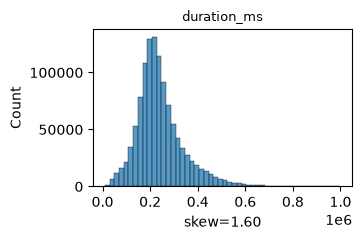

In [11]:
distplots(df[duration_filter], ["duration_ms"])

#### speechiness

In [12]:
speech_filter = df["speechiness"] < 0.6
speech_outliers = df[~speech_filter]
print(len(speech_outliers))
speech_outliers.sample(5)

17857


,artist_name,track_name,track_id,popularity,year,genre,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms,time_signature
736722,Géza Hofi,Második menet: Bakfitty,1wWxB9SAH1EyTWlwEgf4JY,6,2002,k-pop,0.670,0.432,2,-16.817,1,0.938,0.744,0.0,0.756,0.640,116.410,636227,3
947431,Mach One,Crackardy (Skit),2GKZUd19IoT31xPtgjEYqQ,10,2007,german,0.761,0.371,0,-15.393,0,0.747,0.657,0.0,0.673,0.865,94.540,65053,3
934104,Christopher Titus,"September 11, 2001",6bxyLaGwIIjmU9AURox8O0,13,2007,comedy,0.512,0.791,6,-8.516,1,0.940,0.782,0.0,0.905,0.622,86.098,157133,4
1075747,Jessi Campbell,The Bathroom Light,2vkwmc3SuLNw7pFfPA7ZcN,1,2010,comedy,0.533,0.636,11,-13.051,0,0.933,0.938,0.0,0.585,0.471,139.831,269479,5
359712,Bruce Springsteen,Growin' Up (Introduction) - Live at the Walter...,7jTBodGQzYdcXbiTIz5GEe,23,2018,singer-songwriter,0.572,0.343,8,-19.949,1,0.942,0.848,0.0,0.815,0.453,110.737,124307,1


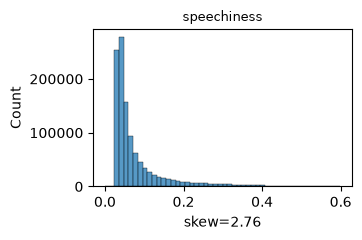

In [13]:
distplots(df[speech_filter], ["speechiness"])

#### time signature

In [14]:
df["time_signature"].value_counts()

time_signature
4    1010673
3     112332
5      22871
1      12660
0       1228
Name: count, dtype: int64

In [15]:
time_filter = df["time_signature"] > 1
df[time_filter].sample(5)

,artist_name,track_name,track_id,popularity,year,genre,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms,time_signature
686145,Bedehusland,Dine Løfter Er Mange,0EqFoGnCoIiYYrHEKtfX3S,9,2001,gospel,0.586,0.340,5,-9.560,1,0.0272,0.637,0.000000,0.0965,0.746,92.352,191960,4
786097,Crazy Cavan,Lonesome Baby Blues (remix),0YdLmRvjXP0CqPXCtLb5LB,1,2003,rock-n-roll,0.570,0.958,9,-5.296,1,0.0706,0.733,0.000062,0.1430,0.704,108.182,122973,4
22405,Stuck in the Sound,Silent and Sweet,7LROnTlpYggwagWNCdXCB1,32,2012,french,0.508,0.765,4,-6.020,1,0.0363,0.152,0.000190,0.0995,0.221,131.615,277773,4
200029,Laidback Luke,The Chase,5EUAT8mNWauk5iiVpbiSoL,16,2015,progressive-house,0.769,0.775,0,-6.937,0,0.1090,0.018,0.006580,0.3880,0.660,125.999,255952,4
1088442,Irmão Lázaro,Naturalmente,5ENZn0xGgG2wjfwMnbPr3B,36,2010,gospel,0.502,0.736,11,-6.626,0,0.0451,0.555,0.000000,0.7750,0.499,128.411,210693,4


problematic column; songs cannot have a time signature of 0 or 1. upon review, the danceability and speechiness of many of these songs are exactly 0, suggesting a mix of mislabeling and these tracks not being songs, but rather sleep / white noise tracks.

#### overall EDA conclusions
- **`duration`** outliers should be removed to include only song-length tracks. we will use the filter to cut out all tracks under 10 seconds or over 17 minutes in length.

- **`speechiness`** outliers should be removed as high speechiness "songs" are likely podcasts or other non-musical media. to ensure this app includes only songs, we will remove tracks with speechiness > 0.6.

these outlier cuts are also beneficial to our model. when we transform / standardize our data before passing it to the model, outliers would have heavily distorted the distributions of the data, forcing typical values into small, heavily clustered ranges while outliers dominated the feature space.

## 3. Feature Decisions


## 4. Cleaning, Transforms, Data Splits

### 4.1 - Data Filtering

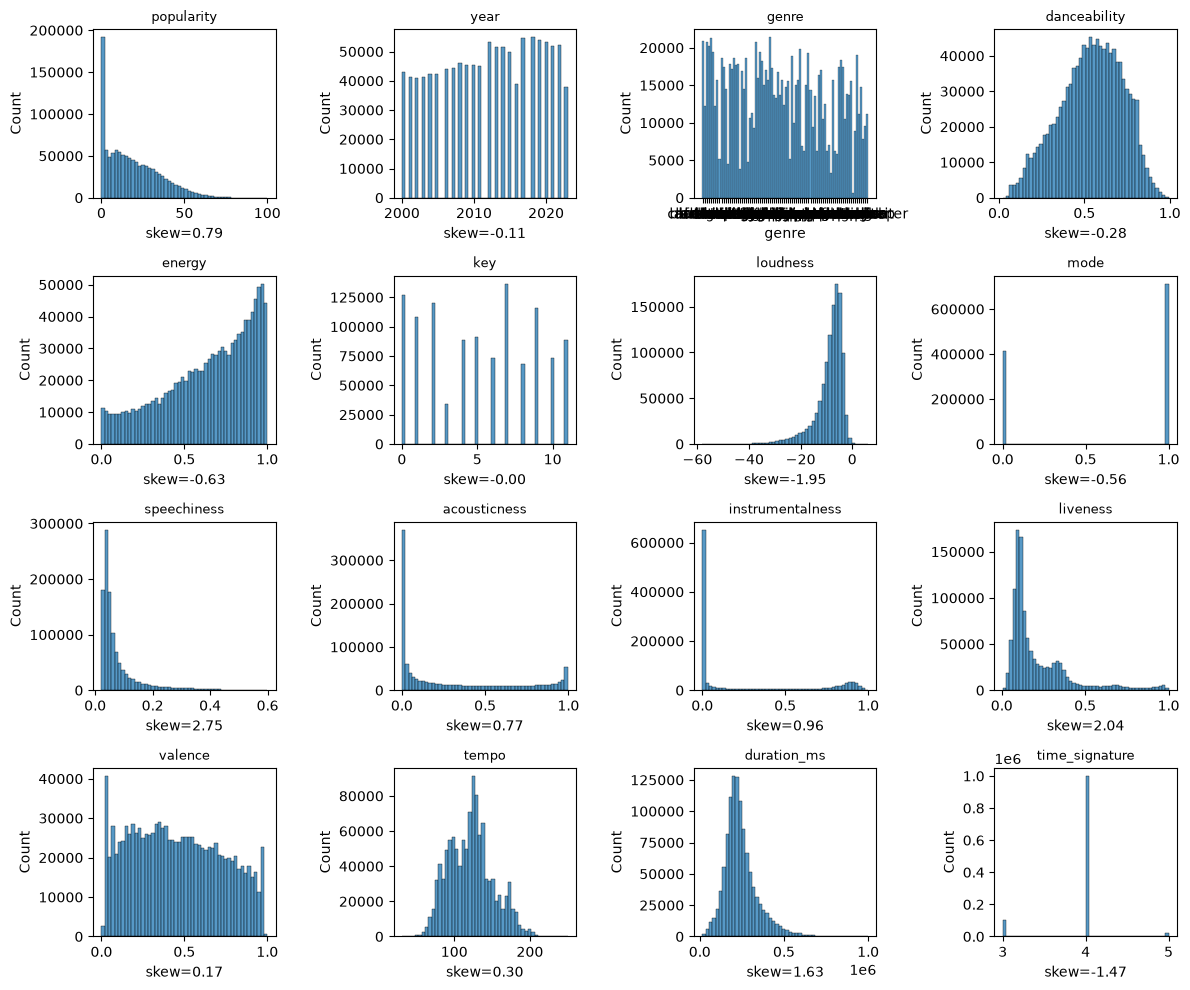

In [16]:
df_filtered = df[time_filter & speech_filter & duration_filter]

distplots(df_filtered, df_filtered.columns[3:])

### 4.2 - Feature Transformation

#### comparing transformations for skewed similarity features

SPEECHINESS


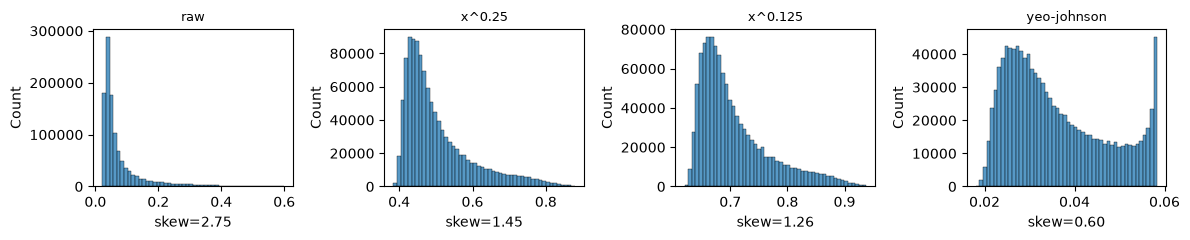

LIVENESS


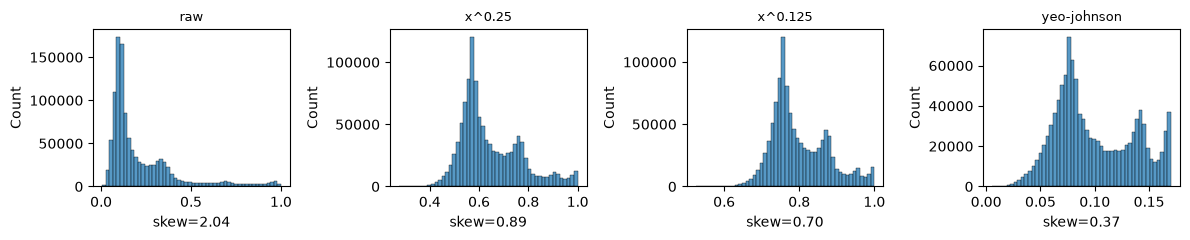

ACOUSTICNESS


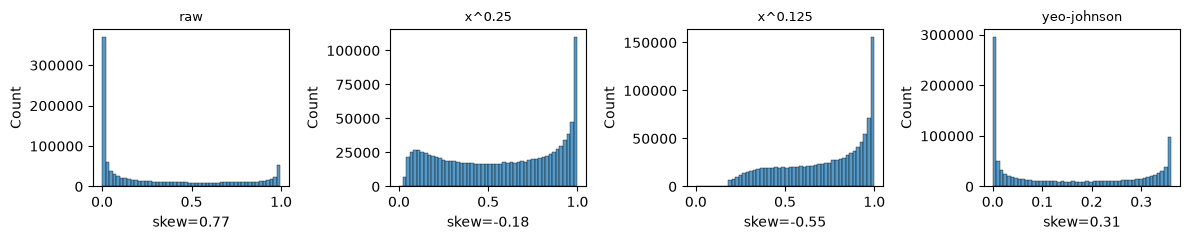

INSTRUMENTALNESS


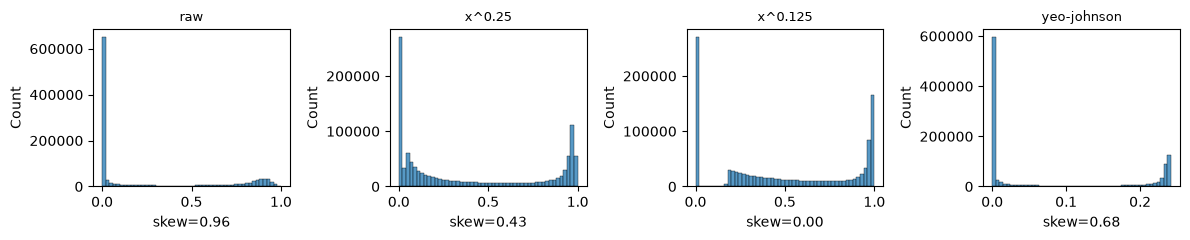

ENERGY


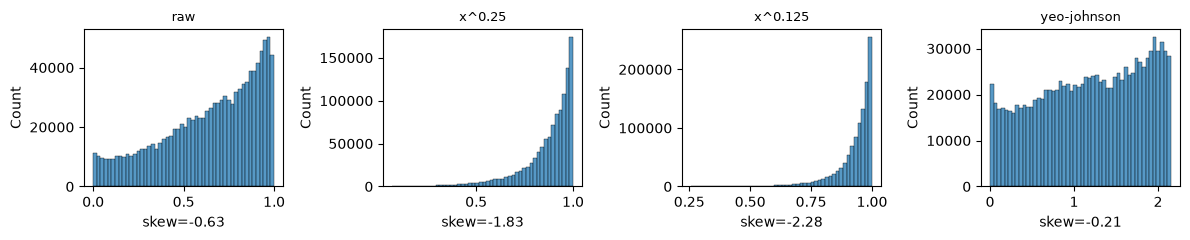

In [17]:
from sklearn.preprocessing import PowerTransformer

for col in ["speechiness", "liveness", "acousticness", "instrumentalness", "energy"]:
    print(col.upper())
    x = df_filtered[col]

    pt = PowerTransformer(method="yeo-johnson", standardize=False)
    yeo = pt.fit_transform(x.to_frame()).ravel()
    # standardize=False to only compare the transform; StandardScaler later on the chosen version

    temp = pd.DataFrame({
        "raw": x,
        #"sqrt": np.sqrt(x),
        "x^0.25": np.power(x, 0.25),
        "x^0.125": np.power(x, 0.125),
        "yeo-johnson": yeo,
    })

    distplots(temp, temp.columns.tolist())

#### feature transform decisions

- **`speechiness`**: **1/8 power transform**. while the yeo-johnson transform yields a smaller |skew|, its right spike (point mass) is undesirable as it means many tracks likely share the same value.

- **`liveness`**: **yeo-johnson transform**. lowest |skew|, smallest spike and no problems with the distribution (multimodal, though this is a characteristic of the dataset).

- **`acousticness`**: **1/4 power transform**. lowest |skew| and smallest spike.

- **`instrumentalness`**: **1/4 power transform**. while the 1/8 power transform yields a smaller |skew|, it has a gap between 0.0 and about 0.2 with a huge spike at 0.0, giving it a lower skew but worse shape. 

- **`energy`**: **yeo-johnson transform**. lower |skew| due to the more even distribution of the data.

### 4.3 - Defining Parent Genres

In [18]:
# 82 Spotify genres -> 10 parent families (for LLM / hard filters)
GENRE_TO_PARENT = {
    # Rock & Alternative
    "alt-rock": "Rock & Alternative",   "emo": "Rock & Alternative",        "goth": "Rock & Alternative",           "guitar": "Rock & Alternative",
    "hard-rock": "Rock & Alternative",  "power-pop": "Rock & Alternative",  "psych-rock": "Rock & Alternative",     "punk": "Rock & Alternative",
    "punk-rock": "Rock & Alternative",  "rock": "Rock & Alternative",       "rock-n-roll": "Rock & Alternative",

    # Metal & Hardcore
    "black-metal": "Metal & Hardcore",  "death-metal": "Metal & Hardcore",  "grindcore": "Metal & Hardcore",        "hardcore": "Metal & Hardcore",
    "hardstyle": "Metal & Hardcore",    "heavy-metal": "Metal & Hardcore",  "industrial": "Metal & Hardcore",       "metal": "Metal & Hardcore",
    "metalcore": "Metal & Hardcore",

    # Electronic & Dance
    "breakbeat": "Electronic & Dance",  "chicago-house": "Electronic & Dance",  "club": "Electronic & Dance",       "dance": "Electronic & Dance",
    "deep-house": "Electronic & Dance", "detroit-techno": "Electronic & Dance", "disco": "Electronic & Dance",      "drum-and-bass": "Electronic & Dance",
    "dubstep": "Electronic & Dance",    "edm": "Electronic & Dance",            "electro": "Electronic & Dance",    "electronic": "Electronic & Dance", "garage": "Electronic & Dance",     "house": "Electronic & Dance",          "minimal-techno": "Electronic & Dance",     "party": "Electronic & Dance",
    "party": "Electronic & Dance",      "progressive-house": "Electronic & Dance",      "techno": "Electronic & Dance",   
    "trance": "Electronic & Dance",

    # Ambient & Chill
    "ambient": "Ambient & Chill",       "chill": "Ambient & Chill",         "new-age": "Ambient & Chill",        "sad": "Ambient & Chill",
    "sad": "Ambient & Chill",           "sleep": "Ambient & Chill",         "trip-hop": "Ambient & Chill",

    # Pop & Global
    "cantopop": "Pop & Global",         "french": "Pop & Global",           "german": "Pop & Global",           "indian": "Pop & Global",
    "indie-pop": "Pop & Global",        "k-pop": "Pop & Global",            "pop": "Pop & Global",              "spanish": "Pop & Global",
    "swedish": "Pop & Global",

    # Hip-Hop & R&B
    "funk": "Hip-Hop & R&B",            "groove": "Hip-Hop & R&B",          "hip-hop": "Hip-Hop & R&B",         "soul": "Hip-Hop & R&B",

    # Latin & Reggae
    "afrobeat": "Latin & Reggae",       "dancehall": "Latin & Reggae",      "dub": "Latin & Reggae",            "forro": "Latin & Reggae",
    "romance": "Latin & Reggae",        "salsa": "Latin & Reggae",          "samba": "Latin & Reggae",          "sertanejo": "Latin & Reggae",
    "sertanejo": "Latin & Reggae",      "ska": "Latin & Reggae",            "tango": "Latin & Reggae",

    # Folk & Acoustic
    "acoustic": "Folk & Acoustic",      "country": "Folk & Acoustic",       "folk": "Folk & Acoustic",          "singer-songwriter": "Folk & Acoustic",
    "songwriter": "Folk & Acoustic",

    # Jazz, Blues & Gospel
    "blues": "Jazz, Blues & Gospel",    "gospel": "Jazz, Blues & Gospel",   "jazz": "Jazz, Blues & Gospel",

    # Classical & Stage
    "classical": "Classical & Stage",   "comedy": "Classical & Stage",      "opera": "Classical & Stage",       "piano": "Classical & Stage",
    "pop-film": "Classical & Stage",    "show-tunes": "Classical & Stage",
}

df_filtered["parent_genre"] = df_filtered["genre"].map(GENRE_TO_PARENT)

# sanity checks
assert df_filtered["parent_genre"].isna().sum() == 0, df_filtered.loc[df_filtered["parent_genre"].isna(), "genre"].unique()
print(df_filtered["parent_genre"].nunique(), "parents")
print(df_filtered["parent_genre"].value_counts())

10 parents
parent_genre
Electronic & Dance      212755
Latin & Reggae          156891
Rock & Alternative      151106
Pop & Global            134880
Metal & Hardcore        123839
Ambient & Chill          90890
Classical & Stage        76723
Folk & Acoustic          69056
Jazz, Blues & Gospel     56600
Hip-Hop & R&B            52694
Name: count, dtype: int64


#### data type optimization

In [19]:
# overview of columns, data types and sample values
for col in df_filtered.columns[3:]:
    print(col.upper(), ":", df_filtered[col].dtype, df_filtered[col].sample(3).values.tolist(), "\n")

POPULARITY : int64 [28, 12, 22] 

YEAR : int64 [2000, 2018, 2009] 

GENRE : str ['opera', 'groove', 'techno'] 

DANCEABILITY : float64 [0.765, 0.236, 0.384] 

ENERGY : float64 [0.934, 0.972, 0.703] 

KEY : int64 [3, 1, 5] 

LOUDNESS : float64 [-7.05, -3.604, -3.006] 

MODE : int64 [1, 1, 1] 

SPEECHINESS : float64 [0.0651, 0.0267, 0.0949] 

ACOUSTICNESS : float64 [0.00443, 0.547, 0.018] 

INSTRUMENTALNESS : float64 [0.000762, 0.0, 0.0] 

LIVENESS : float64 [0.0994, 0.0808, 0.0682] 

VALENCE : float64 [0.58, 0.416, 0.104] 

TEMPO : float64 [123.109, 150.036, 112.035] 

DURATION_MS : int64 [231093, 218450, 238640] 

TIME_SIGNATURE : int64 [4, 4, 4] 

PARENT_GENRE : str ['Metal & Hardcore', 'Metal & Hardcore', 'Latin & Reggae'] 



In [20]:
# type conversions

to_int8 = ["popularity", "key", "mode", "time_signature"]

if "duration_ms" in df_filtered.columns:
    df_filtered["duration_s"] = df_filtered["duration_ms"] // 1000
    df_filtered.drop(columns=["duration_ms"], inplace=True)
    
df_filtered["tempo"] = df_filtered["tempo"].astype(np.int16)

to_int16 = ["year", "duration_s"]
to_category = ["genre", "parent_genre"]
to_float32 = df_filtered.select_dtypes(include=["float64"]).columns

df_filtered[to_int8] = df_filtered[to_int8].astype(np.int8)
df_filtered[to_int16] = df_filtered[to_int16].astype(np.int16)
df_filtered[to_category] = df_filtered[to_category].astype("category")
df_filtered[to_float32] = df_filtered[to_float32].astype(np.float32)

df_filtered.info()

<class 'pandas.DataFrame'>
Index: 1125434 entries, 0 to 1159763
Data columns (total 20 columns):
 #   Column            Non-Null Count    Dtype   
---  ------            --------------    -----   
 0   artist_name       1125419 non-null  str     
 1   track_name        1125433 non-null  str     
 2   track_id          1125434 non-null  str     
 3   popularity        1125434 non-null  int8    
 4   year              1125434 non-null  int16   
 5   genre             1125434 non-null  category
 6   danceability      1125434 non-null  float32 
 7   energy            1125434 non-null  float32 
 8   key               1125434 non-null  int8    
 9   loudness          1125434 non-null  float32 
 10  mode              1125434 non-null  int8    
 11  speechiness       1125434 non-null  float32 
 12  acousticness      1125434 non-null  float32 
 13  instrumentalness  1125434 non-null  float32 
 14  liveness          1125434 non-null  float32 
 15  valence           1125434 non-null  float32 
 16

In [21]:
FILTER_COLS = ["track_id", "artist_name", "track_name", "genre", "parent_genre", "year", "popularity", "loudness", "duration_s", "key", "mode", "tempo"]
filter_df = df_filtered[FILTER_COLS].copy()

filter_df.sample(5).T

,691111,812107,662739,572562,305595
track_id,62sxfDBUZAGyjjsX6xPwXy,0JpvWQpfc6AxT9ZwbOcpgF,706dgBNu2P2bSo2pVnZ0EP,0D0fJnHN5Tj7QTa3rEbLTT,4k7C6iJkilk9GmNuPL8K7r
artist_name,T. M. Krishna,Silbermond,Traditional,Iggy Pop,Lyves
track_name,Sreenivasa,Symphonie,A Birch Grew in the Fields,Frenzy,Darkest Hour
genre,indian,german,sleep,punk,soul
parent_genre,Pop & Global,Pop & Global,Ambient & Chill,Rock & Alternative,Hip-Hop & R&B
year,2001,2004,2000,2022,2017
popularity,0,21,0,41,36
loudness,-7.344,-9.062,-19.778999,-2.806,-9.605
duration_s,329,272,187,180,256
key,2,10,4,8,2


In [22]:
import joblib
import numpy as np
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import FunctionTransformer, PowerTransformer, StandardScaler

POW_125_COLS = ["speechiness"]
POW_25_COLS = ["acousticness", "instrumentalness"]
YEO_COLS = ["liveness", "energy"]
PASSTHROUGH_COLS = ["danceability", "valence", "tempo"]  # scale only

def power_125(X):
    return np.power(np.asarray(X, dtype=np.float64), 0.125)

def power_25(X):
    return np.power(np.asarray(X, dtype=np.float64), 0.25)

preprocess = ColumnTransformer(
    transformers=[
        ("p125", FunctionTransformer(power_125, feature_names_out="one-to-one"), POW_125_COLS),
        ("p25", FunctionTransformer(power_25, feature_names_out="one-to-one"), POW_25_COLS),
        ("yeo", PowerTransformer(method="yeo-johnson", standardize=False), YEO_COLS),
        ("pass", "passthrough", PASSTHROUGH_COLS),
    ],
    remainder="drop",
    verbose_feature_names_out=False,
)

sim_pipeline = Pipeline([
    ("preprocess", preprocess),
    ("scale", StandardScaler()),
])

# fit on RAW filtered features (before your manual df_transformed powers)
SIM_FEATURE_COLS = POW_125_COLS + POW_25_COLS + YEO_COLS + PASSTHROUGH_COLS
X = df_filtered[SIM_FEATURE_COLS]  # raw
X_sim = sim_pipeline.fit_transform(X).astype(np.float32)

FILTER_COLS = ["track_id", "artist_name", "track_name", "genre", "parent_genre", "year", "popularity", "loudness", "duration_s", "key", "mode", "tempo"]
filter_df = df_filtered[FILTER_COLS].copy().reset_index(drop=True)
filter_df.insert(0, "row_id", np.arange(len(filter_df), dtype=np.int32))

assert len(filter_df) == X_sim.shape[0]

joblib.dump(sim_pipeline, "data/sim_pipeline.joblib")
np.save("data/features.npy", X_sim.astype(np.float32))
filter_df.to_parquet("data/filter_df.parquet", index=False) # keep track_id aligned: same row order as df_filtered

In [45]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.decomposition import PCA

df_ml = df_filtered.sample(20000, random_state=42).copy().drop(
    columns=["genre", "track_id", "key", "time_signature", "loudness"]
)

X = df_ml.drop(columns=["artist_name", "track_name", "parent_genre", "popularity"])
y = df_ml["popularity"].astype(np.float64).to_numpy().reshape(-1, 1)

scaler_X = StandardScaler()
X_scaled = scaler_X.fit_transform(X)

# standardize target (compare / train on scaled y; report RMSE on original scale too)
scaler_y = StandardScaler()
y_scaled = scaler_y.fit_transform(y).ravel()

pca = PCA(n_components=7)
X_pca = pca.fit_transform(X_scaled)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_scaled, test_size=0.2, random_state=42
)

model = LinearRegression()
model.fit(X_train, y_train)
y_pred_scaled = model.predict(X_test)

y_test_orig = scaler_y.inverse_transform(y_test.reshape(-1, 1)).ravel()
y_pred_orig = scaler_y.inverse_transform(y_pred_scaled.reshape(-1, 1)).ravel()

mse = mean_squared_error(y_test_orig, y_pred_orig)
rmse = np.sqrt(mse)

print(f"y mean={float(y.mean()):.2f}, y std={float(y.std()):.2f}")
print(f"RMSE (original popularity scale): {rmse:.4f}")
print(f"RMSE (standardized y): {np.sqrt(mean_squared_error(y_test, y_pred_scaled)):.4f}")

results = pd.DataFrame({"y_test": y_test_orig, "y_pred": y_pred_orig})
results

y mean=18.28, y std=15.77
RMSE (original popularity scale): 14.3111
RMSE (standardized y): 0.9077


,y_test,y_pred
0,34.0,33.225758
1,0.0,29.175304
2,1.0,16.011684
3,26.0,21.411182
4,36.0,12.238982
...,...,...
3995,19.0,14.716013
3996,41.0,26.324060
3997,35.0,23.369411
3998,8.0,10.613327


### Neural net: predict `parent_genre`

Audio features → 10-way `parent_genre` (`MLPClassifier`).

**What the first runs showed**
- Majority baseline ≈ **19%**; unweighted MLP ≈ **44–48%** — clearly learning signal, but parent genres overlap in audio space.
- **Strong:** Metal, Electronic, Latin. **Weak:** Pop & Global (bleeds into Folk/Latin/Rock), Jazz/Blues, Hip-Hop.
- Full `balanced` sample weights lift minority recall a bit but **hurt accuracy** more than they help macro-F1.
- Soft weights (`√balanced`) are the better tradeoff; **keep `loudness`** (dropping it was hurting genre separation); more data (50k) > deeper nets.

**This cell:** 50k stratified split, soft class weights, `(192, 96)` MLP, report accuracy + macro-F1 + confusion matrix.

Accuracy: 0.5890  |  macro-F1: 0.5348  |  iters: 62
Features: ['popularity', 'year', 'danceability', 'energy', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'duration_s']
                   precision    recall  f1-score   support

         acoustic       0.71      0.57      0.63      1810
          country       0.62      0.72      0.67      1535
             folk       0.56      0.61      0.58      1390
singer-songwriter       0.46      0.45      0.46      1210
       songwriter       0.26      0.49      0.34        55

         accuracy                           0.59      6000
        macro avg       0.52      0.57      0.53      6000
     weighted avg       0.60      0.59      0.59      6000



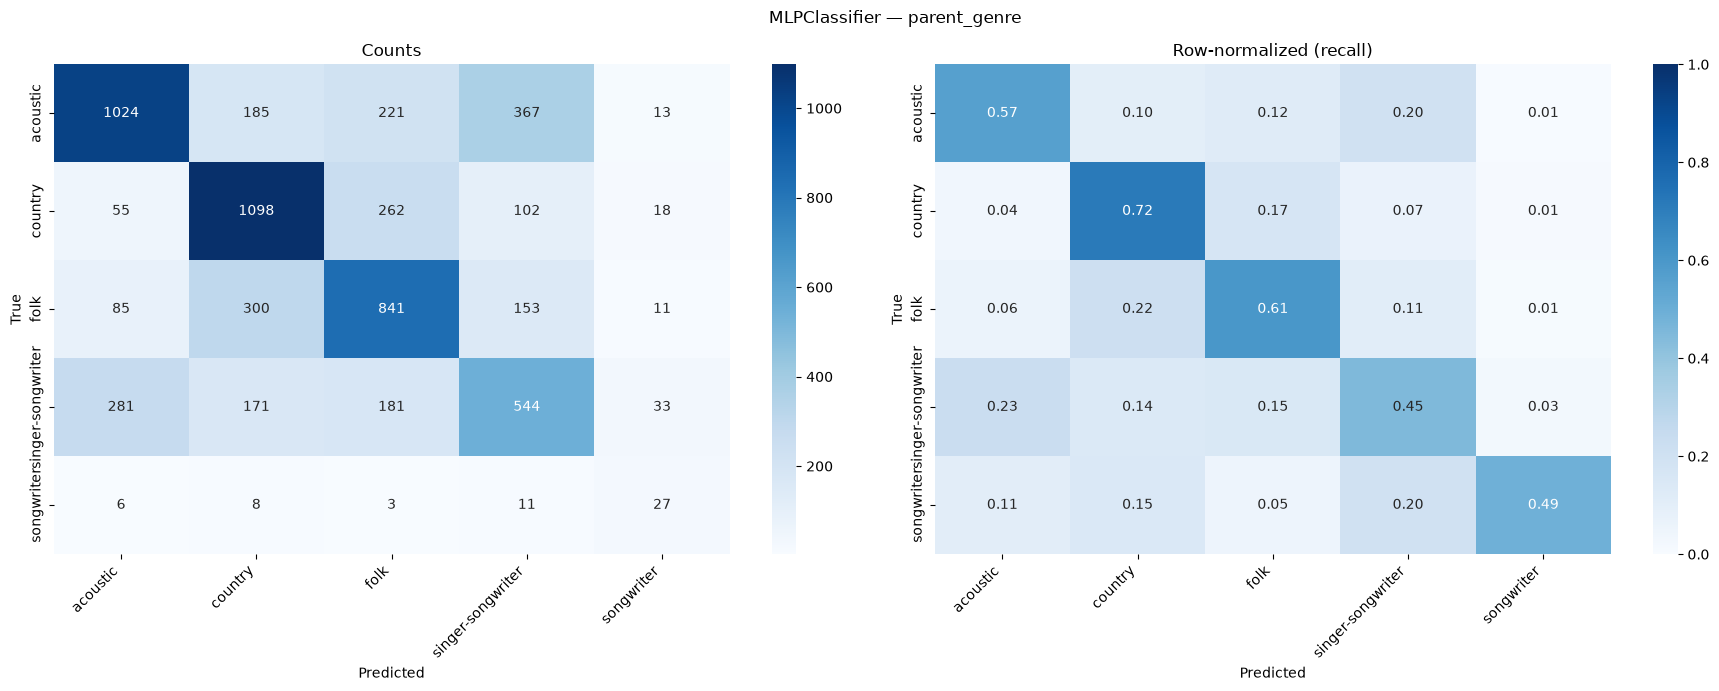

Accuracy: 0.6522  |  macro-F1: 0.6527  |  iters: 43
Features: ['popularity', 'year', 'danceability', 'energy', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'duration_s']
              precision    recall  f1-score   support

    afrobeat       0.60      0.53      0.56       471
   dancehall       0.67      0.77      0.72       722
         dub       0.79      0.70      0.74       712
       forro       0.64      0.60      0.62       735
     romance       0.63      0.69      0.66       238
       salsa       0.66      0.63      0.64       671
       samba       0.50      0.54      0.52       696
   sertanejo       0.60      0.64      0.62       670
         ska       0.68      0.64      0.66       529
       tango       0.79      0.78      0.78       556

    accuracy                           0.65      6000
   macro avg       0.65      0.65      0.65      6000
weighted avg       0.66      0.65      0.65      6000



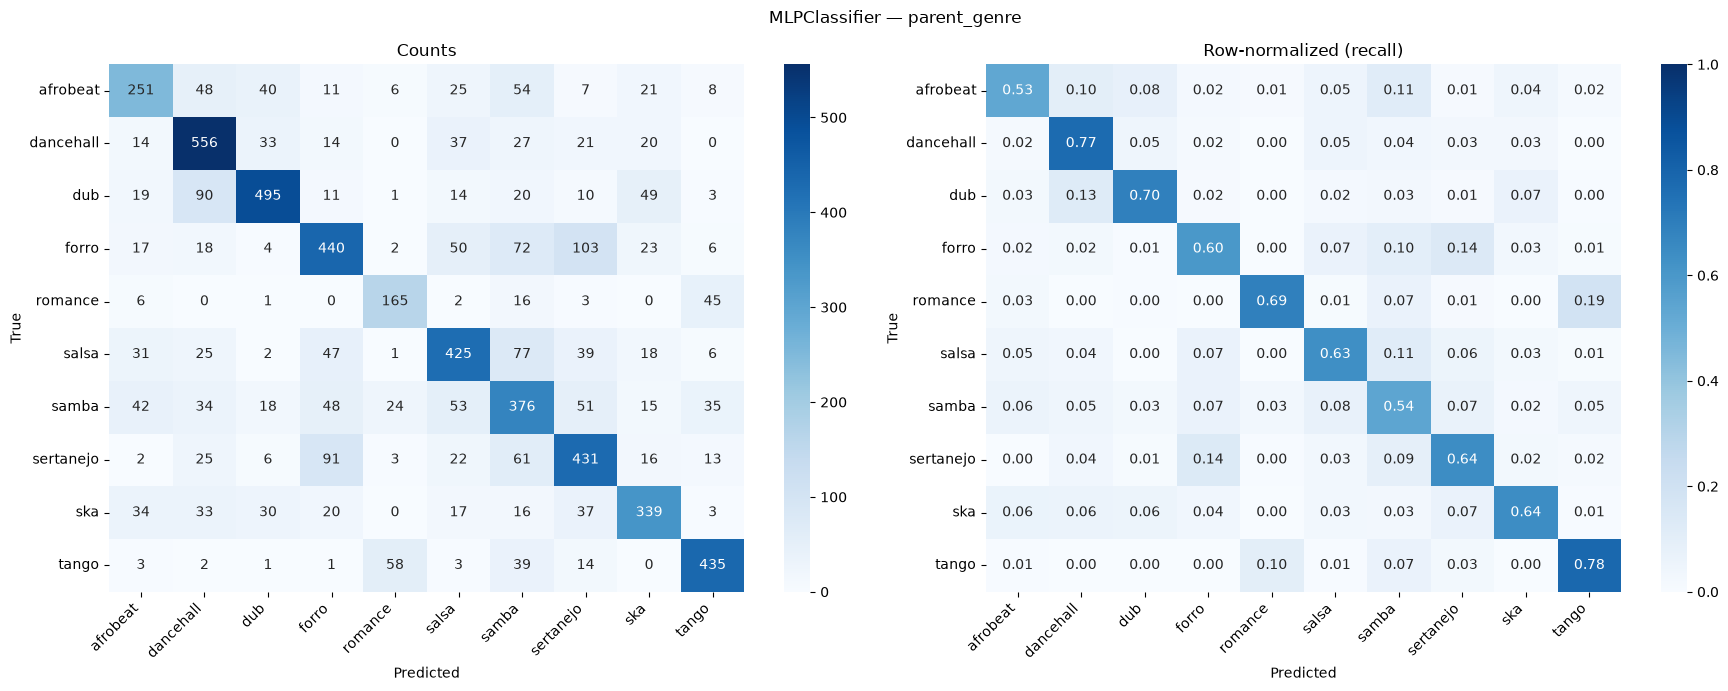

Accuracy: 0.5323  |  macro-F1: 0.4759  |  iters: 32
Features: ['popularity', 'year', 'danceability', 'energy', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'duration_s']
              precision    recall  f1-score   support

    alt-rock       0.57      0.71      0.63       830
         emo       0.45      0.46      0.45       815
        goth       0.46      0.47      0.47       673
      guitar       0.83      0.76      0.79       691
   hard-rock       0.44      0.41      0.42       559
   power-pop       0.70      0.53      0.60       682
  psych-rock       0.40      0.36      0.38       488
        punk       0.27      0.21      0.24       237
   punk-rock       0.28      0.21      0.24       270
        rock       0.31      0.39      0.35       132
 rock-n-roll       0.59      0.74      0.66       623

    accuracy                           0.53      6000
   macro avg       0.48      0.48      0.48      6000
weighted avg  

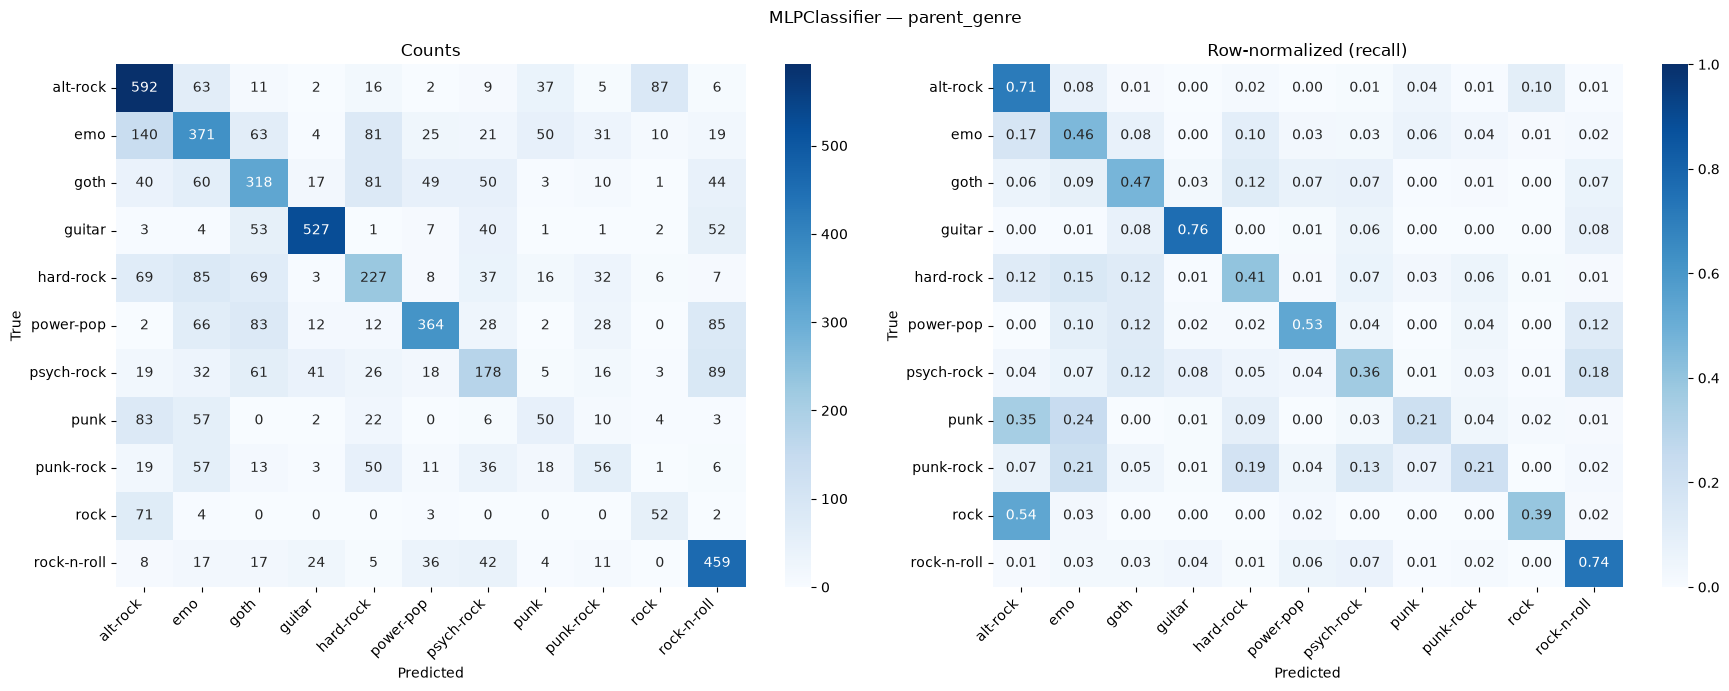

Accuracy: 0.6838  |  macro-F1: 0.6870  |  iters: 44
Features: ['popularity', 'year', 'danceability', 'energy', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'duration_s']
              precision    recall  f1-score   support

     ambient       0.62      0.63      0.62      1322
       chill       0.70      0.69      0.69      1236
     new-age       0.69      0.67      0.68      1291
         sad       0.61      0.82      0.70       384
       sleep       0.80      0.74      0.77      1035
    trip-hop       0.67      0.64      0.66       732

    accuracy                           0.68      6000
   macro avg       0.68      0.70      0.69      6000
weighted avg       0.69      0.68      0.68      6000



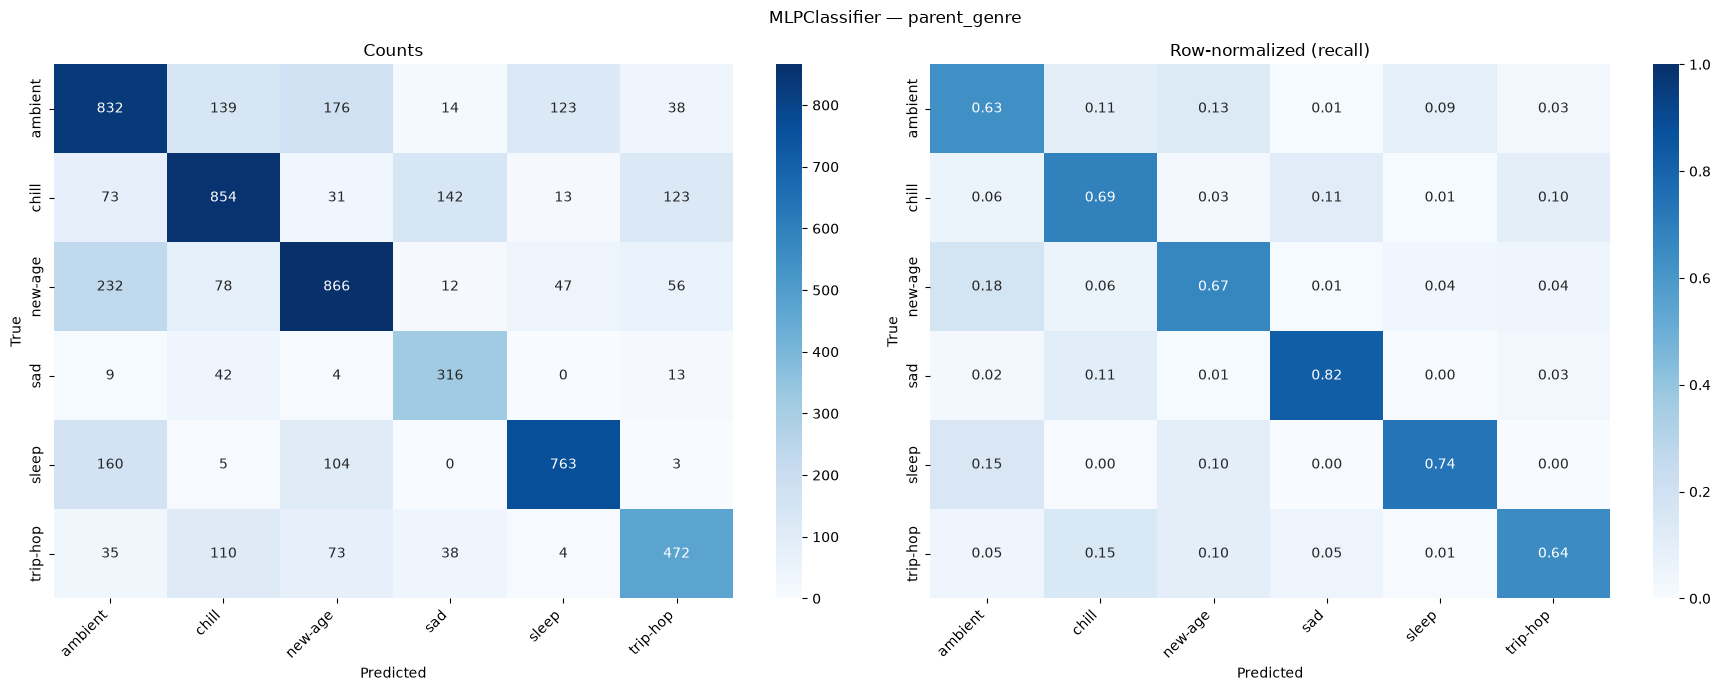

Accuracy: 0.6415  |  macro-F1: 0.6320  |  iters: 59
Features: ['popularity', 'year', 'danceability', 'energy', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'duration_s']
              precision    recall  f1-score   support

 black-metal       0.69      0.62      0.65      1015
 death-metal       0.51      0.51      0.51       851
   grindcore       0.79      0.84      0.82       670
    hardcore       0.66      0.54      0.59       768
   hardstyle       0.80      0.82      0.81       595
 heavy-metal       0.77      0.66      0.71       726
  industrial       0.65      0.60      0.62       744
       metal       0.51      0.79      0.62       332
   metalcore       0.30      0.45      0.36       299

    accuracy                           0.64      6000
   macro avg       0.63      0.65      0.63      6000
weighted avg       0.66      0.64      0.64      6000



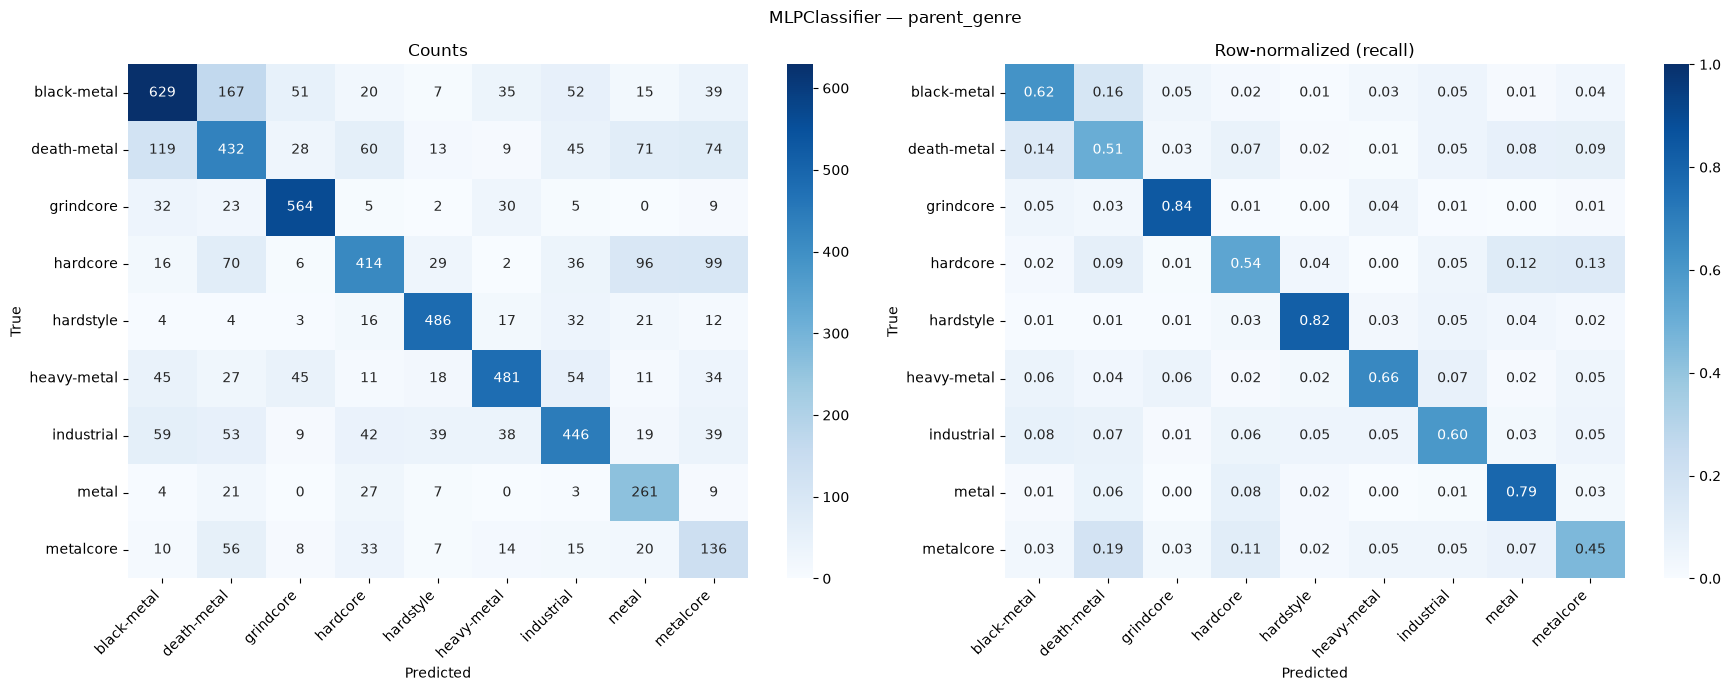

Accuracy: 0.7425  |  macro-F1: 0.7440  |  iters: 44
Features: ['popularity', 'year', 'danceability', 'energy', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'duration_s']
              precision    recall  f1-score   support

       blues       0.68      0.66      0.67      2076
      gospel       0.77      0.78      0.77      2256
        jazz       0.78      0.79      0.79      1668

    accuracy                           0.74      6000
   macro avg       0.74      0.74      0.74      6000
weighted avg       0.74      0.74      0.74      6000



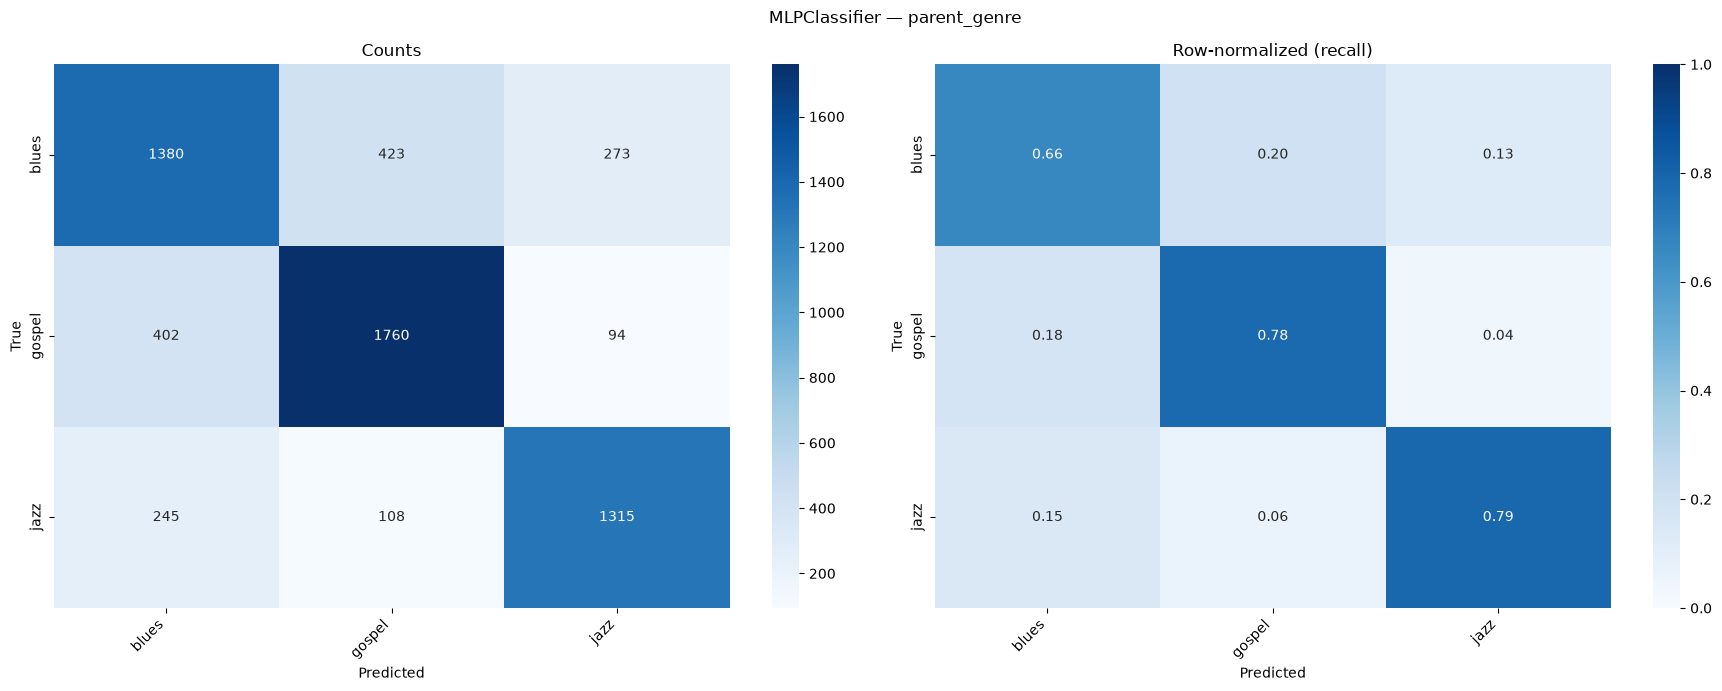

Accuracy: 0.4745  |  macro-F1: 0.4372  |  iters: 57
Features: ['popularity', 'year', 'danceability', 'energy', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'duration_s']
                   precision    recall  f1-score   support

        breakbeat       0.56      0.42      0.48       334
    chicago-house       0.45      0.42      0.43       153
             club       0.57      0.44      0.50       408
            dance       0.59      0.78      0.68       479
       deep-house       0.44      0.30      0.36       500
   detroit-techno       0.35      0.31      0.33       108
            disco       0.53      0.34      0.42       483
    drum-and-bass       0.75      0.68      0.71       417
          dubstep       0.40      0.47      0.44       133
              edm       0.30      0.27      0.29       295
          electro       0.47      0.39      0.42       326
       electronic       0.28      0.41      0.33       267
    

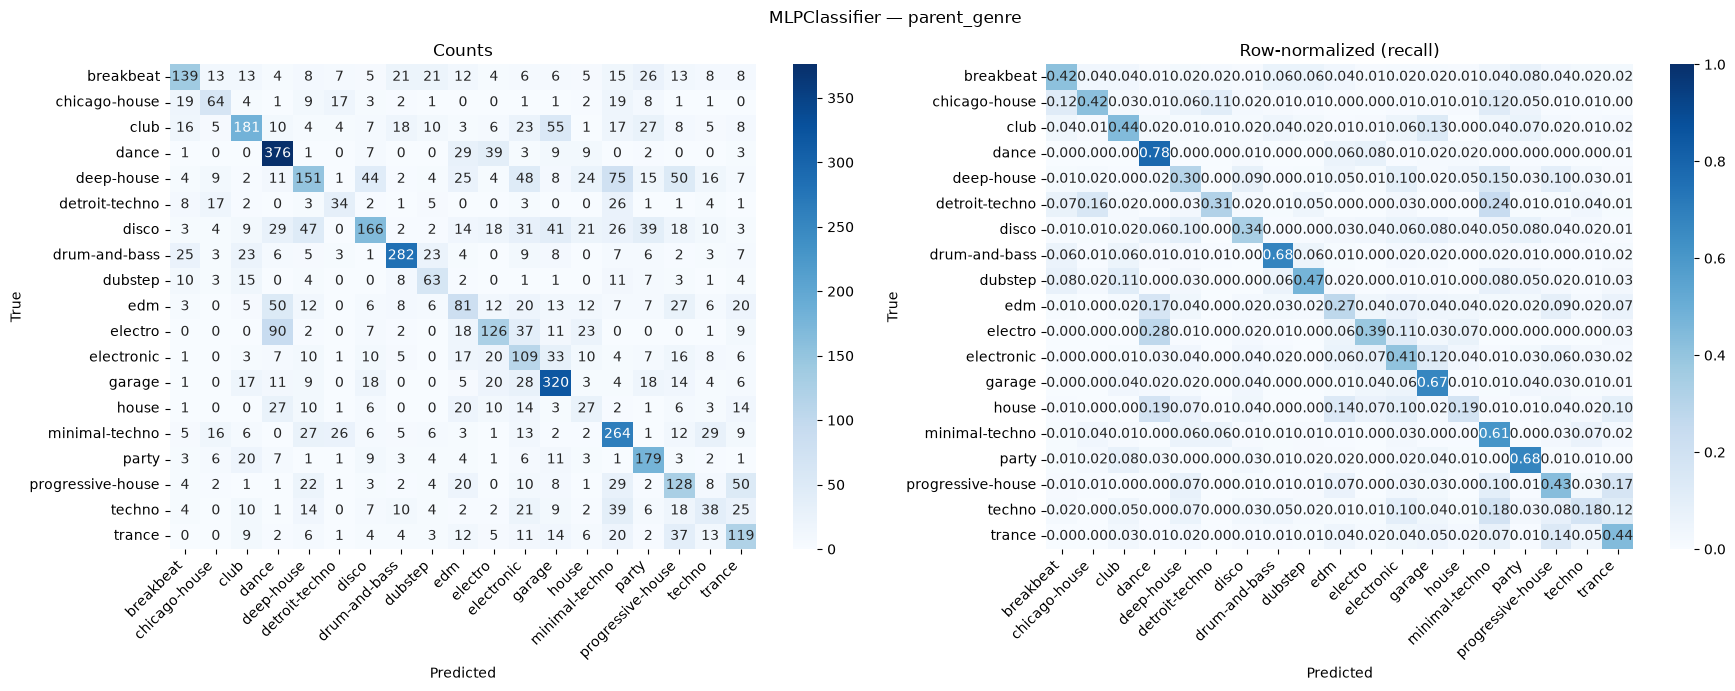

Accuracy: 0.4795  |  macro-F1: 0.4750  |  iters: 37
Features: ['popularity', 'year', 'danceability', 'energy', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'duration_s']
              precision    recall  f1-score   support

    cantopop       0.52      0.65      0.58       702
      french       0.46      0.30      0.37       817
      german       0.45      0.47      0.46       708
      indian       0.75      0.69      0.72       835
   indie-pop       0.35      0.51      0.42       439
       k-pop       0.51      0.50      0.50       875
         pop       0.53      0.69      0.60       271
     spanish       0.35      0.34      0.34       846
     swedish       0.32      0.26      0.29       507

    accuracy                           0.48      6000
   macro avg       0.47      0.49      0.48      6000
weighted avg       0.48      0.48      0.48      6000



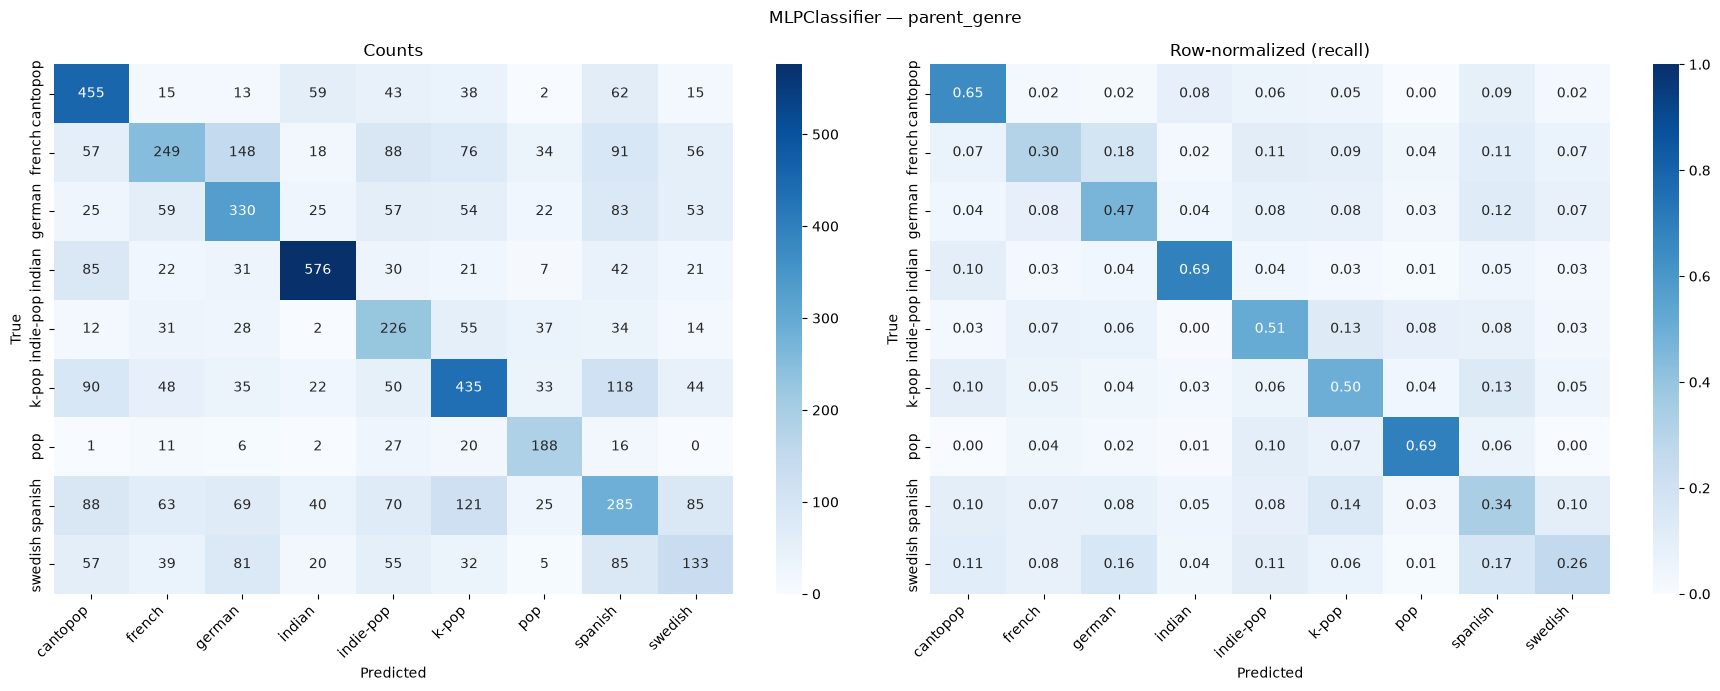

Accuracy: 0.7280  |  macro-F1: 0.7005  |  iters: 40
Features: ['popularity', 'year', 'danceability', 'energy', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'duration_s']
              precision    recall  f1-score   support

   classical       0.83      0.76      0.80      1364
      comedy       0.59      0.60      0.60       349
       opera       0.72      0.76      0.74      1121
       piano       0.67      0.69      0.68      1071
    pop-film       0.80      0.83      0.82      1293
  show-tunes       0.58      0.56      0.57       802

    accuracy                           0.73      6000
   macro avg       0.70      0.70      0.70      6000
weighted avg       0.73      0.73      0.73      6000



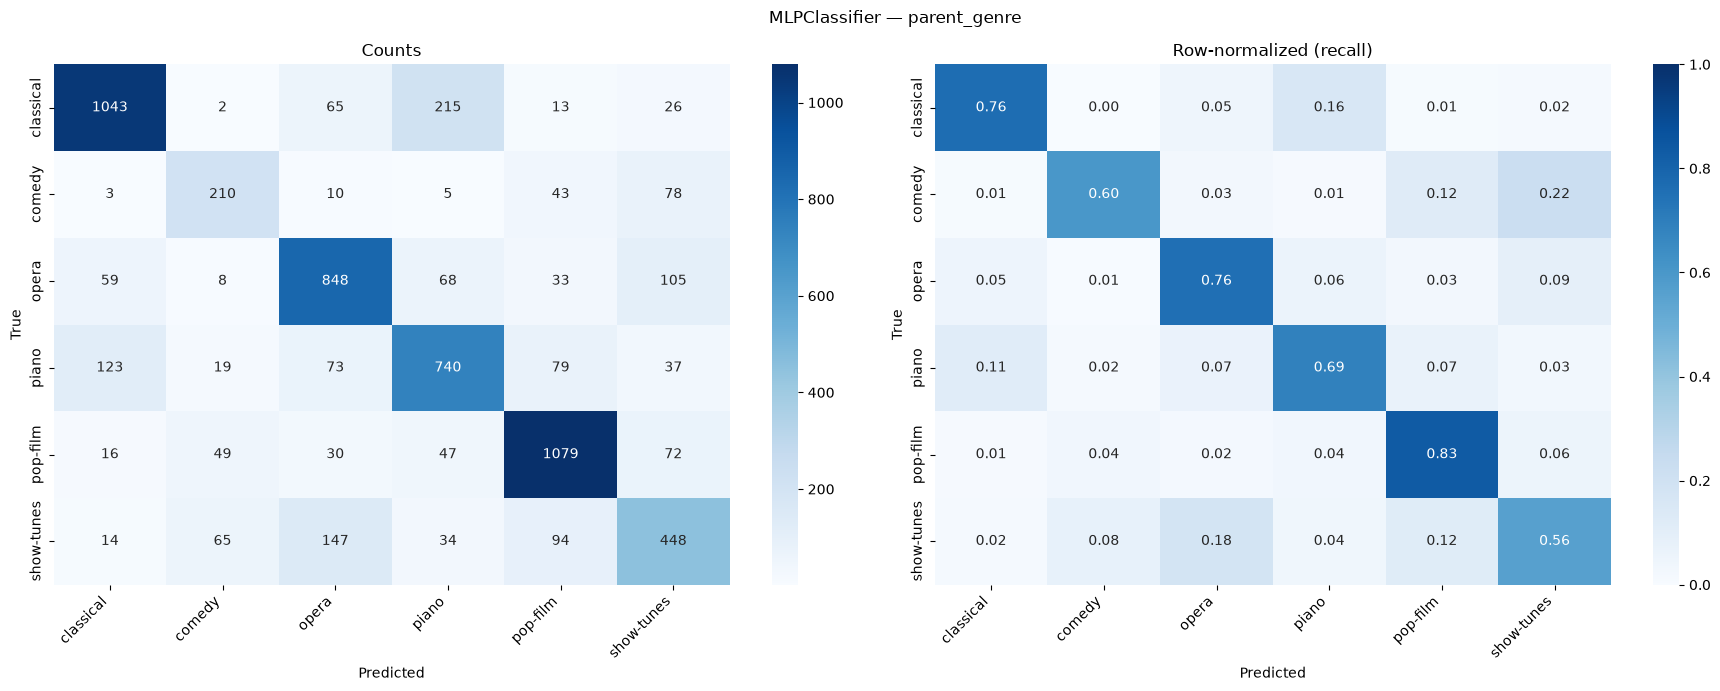

Accuracy: 0.7682  |  macro-F1: 0.7553  |  iters: 41
Features: ['popularity', 'year', 'danceability', 'energy', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'duration_s']
              precision    recall  f1-score   support

        funk       0.73      0.58      0.65      1707
      groove       0.87      0.85      0.86      1508
     hip-hop       0.82      0.92      0.87      1757
        soul       0.60      0.70      0.65      1028

    accuracy                           0.77      6000
   macro avg       0.76      0.76      0.76      6000
weighted avg       0.77      0.77      0.76      6000



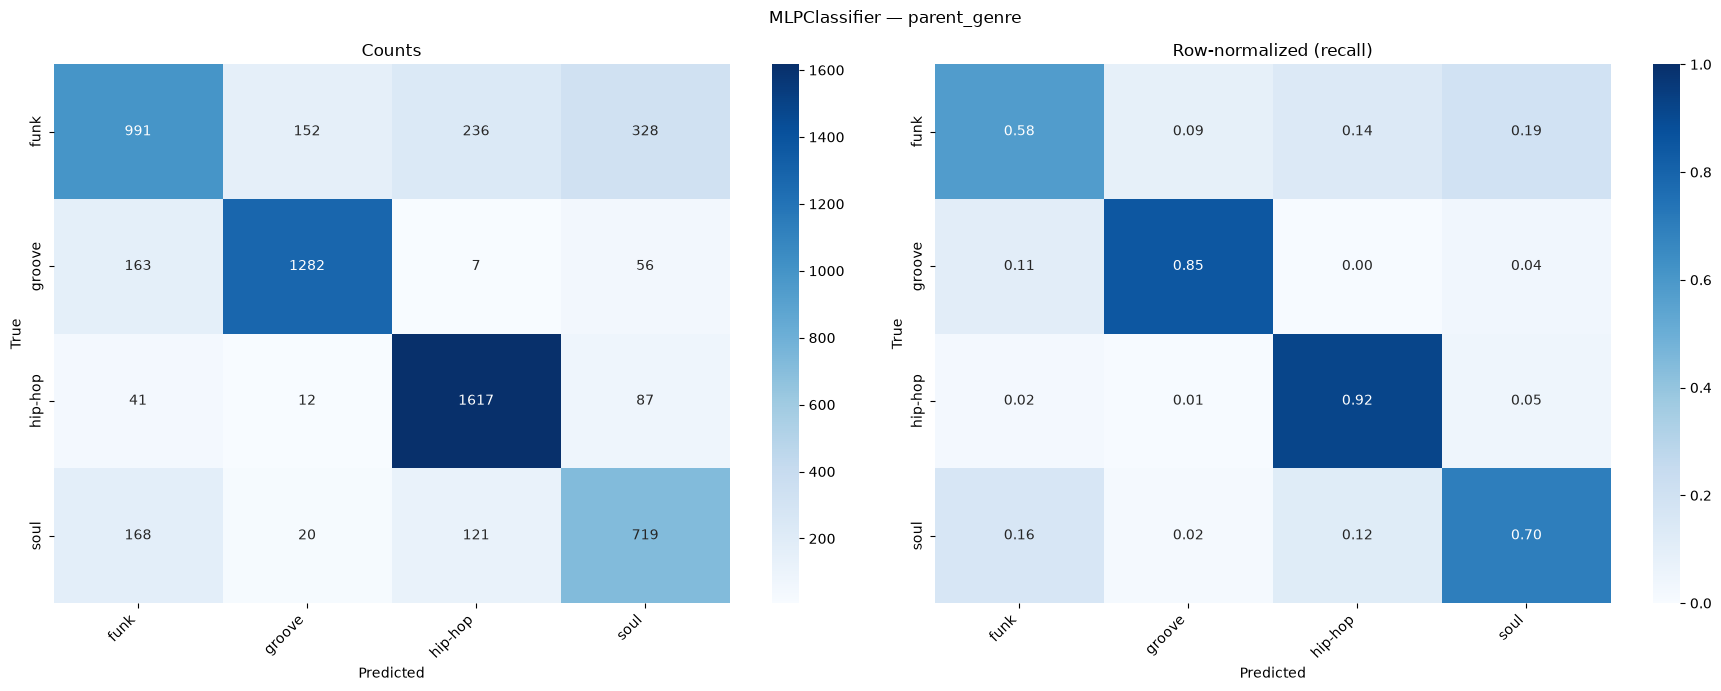

In [46]:
from sklearn.neural_network import MLPClassifier
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

for parent_genre in df_filtered["parent_genre"].unique():
    df_clf = df_filtered[df_filtered["parent_genre"] == parent_genre].sample(30000).copy()

    # Drop IDs / label / discrete music-theory cols. Keep loudness (helps genre).
    drop_cols = [
        "genre", "track_id", "artist_name", "track_name",
        "key", "time_signature", "parent_genre",
    ]
    drop_cols = [c for c in drop_cols if c in df_clf.columns]
    if "duration_ms" in df_clf.columns and "duration_s" in df_clf.columns:
        drop_cols.append("duration_ms")

    X_clf = df_clf.drop(columns=drop_cols)
    y_clf = df_clf["genre"].astype(str)

    scaler_clf = StandardScaler()
    X_clf_scaled = scaler_clf.fit_transform(X_clf)

    X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(
        X_clf_scaled, y_clf, test_size=0.2, random_state=42, stratify=y_clf
    )

    # Soft class weights: √(balanced). Full balanced over-penalizes majority classes.
    classes = np.unique(y_train_clf)
    cw = compute_class_weight("balanced", classes=classes, y=y_train_clf)
    sample_weight = np.sqrt(y_train_clf.map(dict(zip(classes, cw))).to_numpy())

    nn_clf = MLPClassifier(
        hidden_layer_sizes=(192, 96),
        activation="relu",
        solver="adam",
        alpha=1e-4,
        batch_size=256,
        learning_rate_init=1e-3,
        max_iter=250,
        early_stopping=True,
        validation_fraction=0.1,
        n_iter_no_change=15,
        random_state=42,
    )

    nn_clf.fit(X_train_clf, y_train_clf, sample_weight=sample_weight)
    y_pred_clf = nn_clf.predict(X_test_clf)

    acc = accuracy_score(y_test_clf, y_pred_clf)
    macro_f1 = f1_score(y_test_clf, y_pred_clf, average="macro")
    print(f"Accuracy: {acc:.4f}  |  macro-F1: {macro_f1:.4f}  |  iters: {nn_clf.n_iter_}")
    print(f"Features: {list(X_clf.columns)}")
    print(classification_report(y_test_clf, y_pred_clf))

    labels = sorted(y_clf.unique())
    cm = confusion_matrix(y_test_clf, y_pred_clf, labels=labels)
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

    fig, axes = plt.subplots(1, 2, figsize=(18, 7))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=labels, yticklabels=labels, ax=axes[0])
    axes[0].set_title("Counts")
    sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap="Blues", xticklabels=labels, yticklabels=labels, ax=axes[1], vmin=0, vmax=max(cm_norm.max(), 1))
    axes[1].set_title("Row-normalized (recall)")
    for ax in axes:
        ax.set_xlabel("Predicted")
        ax.set_ylabel("True")
        ax.tick_params(axis="x", rotation=45)
        for label in ax.get_xticklabels():
            label.set_ha("right")
    plt.suptitle("MLPClassifier — parent_genre")
    plt.tight_layout()
    plt.show()

